## VibeChecker Data Processing Pipeline  
**Apan 5570PS**  
*Myles Willett & Mariela Bracete*

### Library and Data Imports

In [1]:
#Importing libraries

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Setting file paths

#Base folder
BASE_DIR = Path.cwd()

#Data folder
DATA_DIR = BASE_DIR / "data"

print("Working directory:", BASE_DIR)
print("Data folder exists:", DATA_DIR.exists())

print("\nFiles found:")
for f in sorted(DATA_DIR.glob("*.csv")):
    print("-", f.name)

Working directory: /Users/marielabracete/VibeChecker
Data folder exists: True

Files found:
- vibe_data_cafe1.csv
- vibe_data_cafe2.csv
- vibe_data_cafe3.csv
- vibe_data_cafe4.csv
- vibe_data_club1.csv
- vibe_data_club2.csv
- vibe_data_club3.csv
- vibe_data_club4.csv
- vibe_data_library1.csv
- vibe_data_library2.csv
- vibe_data_library3.csv
- vibe_data_library4.csv


In [3]:
# =====================
# DATASET MODE TOGGLE
# =====================

# Set to True for full model-building dataset (12 runs)
# Set to False for validation/test dataset (random 6 runs only)
USE_FULL_DATASET = True

if USE_FULL_DATASET:
    print("Running FULL dataset (12 runs)")

    file_map = {
        "library_run_1": DATA_DIR / "vibe_data_library1.csv",
        "library_run_2": DATA_DIR / "vibe_data_library2.csv",
        "library_run_3": DATA_DIR / "vibe_data_library3.csv",
        "library_run_4": DATA_DIR / "vibe_data_library4.csv",

        "cafe_run_1": DATA_DIR / "vibe_data_cafe1.csv",
        "cafe_run_2": DATA_DIR / "vibe_data_cafe2.csv",
        "cafe_run_3": DATA_DIR / "vibe_data_cafe3.csv",
        "cafe_run_4": DATA_DIR / "vibe_data_cafe4.csv",

        "club_run_1": DATA_DIR / "vibe_data_club1.csv",
        "club_run_2": DATA_DIR / "vibe_data_club2.csv",
        "club_run_3": DATA_DIR / "vibe_data_club3.csv",
        "club_run_4": DATA_DIR / "vibe_data_club4.csv",
    }

else:
    print("Running RANDOM VALIDATION dataset")

    import random

    RANDOM_SEED = 42
    RUNS_PER_ENV_FOR_VALIDATION = 2

    all_files_by_env = {
        "library": {
            "library_run_1": DATA_DIR / "vibe_data_library1.csv",
            "library_run_2": DATA_DIR / "vibe_data_library2.csv",
            "library_run_3": DATA_DIR / "vibe_data_library3.csv",
            "library_run_4": DATA_DIR / "vibe_data_library4.csv",
        },
        "cafe": {
            "cafe_run_1": DATA_DIR / "vibe_data_cafe1.csv",
            "cafe_run_2": DATA_DIR / "vibe_data_cafe2.csv",
            "cafe_run_3": DATA_DIR / "vibe_data_cafe3.csv",
            "cafe_run_4": DATA_DIR / "vibe_data_cafe4.csv",
        },
        "club": {
            "club_run_1": DATA_DIR / "vibe_data_club1.csv",
            "club_run_2": DATA_DIR / "vibe_data_club2.csv",
            "club_run_3": DATA_DIR / "vibe_data_club3.csv",
            "club_run_4": DATA_DIR / "vibe_data_club4.csv",
        },
    }

    random.seed(RANDOM_SEED)

    file_map = {}

    for env, runs in all_files_by_env.items():
        selected_runs = random.sample(list(runs.keys()), RUNS_PER_ENV_FOR_VALIDATION)

        for run_name in selected_runs:
            file_map[run_name] = runs[run_name]

    print("Selected validation runs:")
    for run_name in sorted(file_map):
        print("-", run_name)

# Sanity check
for run_name, path in file_map.items():
    print(run_name, "->", path.exists())

Running FULL dataset (12 runs)
library_run_1 -> True
library_run_2 -> True
library_run_3 -> True
library_run_4 -> True
cafe_run_1 -> True
cafe_run_2 -> True
cafe_run_3 -> True
cafe_run_4 -> True
club_run_1 -> True
club_run_2 -> True
club_run_3 -> True
club_run_4 -> True


The block above allows switching between:
- Full dataset (12 runs) for final analysis
- Test dataset (subset of just 6 runs) for end-to-end validation

In [4]:
#Defining helper function to load and label each file for merging

def load_run(file_path, run_name):
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = [col.strip() for col in df.columns]

    # Add metadata
    df["run_name"] = run_name

    env, run_num = run_name.split("_run_")
    df["environment"] = env
    df["run_number"] = f"run_{run_num}"

    return df

### Data Exploration and Validation

In [5]:
#Loading and combining the datasets

dfs = []

for run_name, file_path in file_map.items():
    df = load_run(file_path, run_name)
    dfs.append(df)

vibe_df = pd.concat(dfs, ignore_index=True)

print("Shape:", vibe_df.shape)
vibe_df.head()

Shape: (2202, 11)


,timestamp_received,device_id,ip,location_id,session_id,timestamp_device,temperature_f,noise_level_db,run_name,environment,run_number
0,2026-04-10T13:42:21.995386,core2_mcb2318,192.168.1.88,library,run_1,1775828541,70.0,25.00,library_run_1,library,run_1
1,2026-04-10T13:42:22.478250,core2_mcb2318,192.168.1.88,library,run_1,1775828542,70.0,26.50,library_run_1,library,run_1
2,2026-04-10T13:42:23.527160,core2_mcb2318,192.168.1.88,library,run_1,1775828543,70.0,31.82,library_run_1,library,run_1
3,2026-04-10T13:42:24.541707,core2_mcb2318,192.168.1.88,library,run_1,1775828544,70.0,32.43,library_run_1,library,run_1
4,2026-04-10T13:42:25.331345,core2_mcb2318,192.168.1.88,library,run_1,1775828545,70.0,33.74,library_run_1,library,run_1


In [6]:
#Validation Step  1: Inspecting columns and data types

print("Rows per run:")
print(vibe_df.groupby(["environment", "run_number"]).size())

print("\nMissing values:")
print(vibe_df.isna().sum())

Rows per run:
environment  run_number
cafe         run_1         181
             run_2         182
             run_3         187
             run_4         186
club         run_1         185
             run_2         179
             run_3         186
             run_4         186
library      run_1         179
             run_2         180
             run_3         185
             run_4         186
dtype: int64

Missing values:
timestamp_received    0
device_id             0
ip                    0
location_id           0
session_id            0
timestamp_device      0
temperature_f         0
noise_level_db        0
run_name              0
environment           0
run_number            0
dtype: int64


In [7]:
#Validation Step 2: Fixing numeric columns

cols = ["temperature_f", "noise_level_db", "timestamp_device"]

for col in cols:
    if col in vibe_df.columns:
        vibe_df[col] = pd.to_numeric(vibe_df[col], errors="coerce")

vibe_df.dtypes

timestamp_received     object
device_id              object
ip                     object
location_id            object
session_id             object
timestamp_device        int64
temperature_f         float64
noise_level_db        float64
run_name               object
environment            object
run_number             object
dtype: object

In [8]:
#Removing start up noise from all datasets, since first sensor reading was consistently lower than subsequent readings across all datasets.

vibe_df_clean = (
    vibe_df
    .groupby("run_name", group_keys=False)
    .apply(lambda x: x.iloc[2:])  # drop first 2 rows per run
    .reset_index(drop=True)
)

print("After cleaning:")
print(vibe_df_clean.groupby(["environment", "run_number"]).size())

After cleaning:
environment  run_number
cafe         run_1         179
             run_2         180
             run_3         185
             run_4         184
club         run_1         183
             run_2         177
             run_3         184
             run_4         184
library      run_1         177
             run_2         178
             run_3         183
             run_4         184
dtype: int64


/var/folders/nw/1xpl73k10gs91tkrntbvfp7c0000gn/T/ipykernel_62099/128418628.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[2:])  # drop first 2 rows per run


In [9]:
#Generating summary stats

env_summary = (
    vibe_df_clean
    .groupby("environment")
    .agg(
        mean_noise=("noise_level_db", "mean"),
        median_noise=("noise_level_db", "median"),
        std_noise=("noise_level_db", "std"),
        min_noise=("noise_level_db", "min"),
        max_noise=("noise_level_db", "max"),
        mean_temp=("temperature_f", "mean"),
        count=("noise_level_db", "size")
    )
    .sort_values("mean_noise")
)

env_summary

,mean_noise,median_noise,std_noise,min_noise,max_noise,mean_temp,count
environment,,,,,,,
library,29.867355,28.805,4.238627,24.79,58.21,69.800152,722
cafe,43.266621,43.290,2.786874,32.37,55.12,72.244231,728
club,71.018887,72.160,4.946228,28.17,78.61,71.287514,728


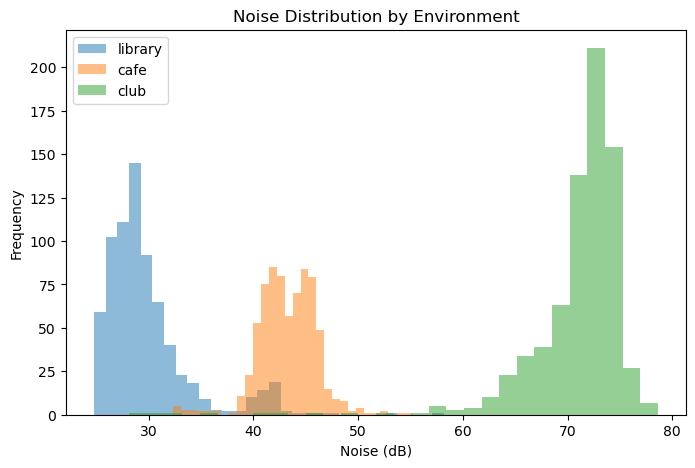

In [10]:
#Visualizing separation

plt.figure(figsize=(8, 5))

for env in ["library", "cafe", "club"]:
    subset = vibe_df_clean[vibe_df_clean["environment"] == env]
    plt.hist(subset["noise_level_db"], bins=30, alpha=0.5, label=env)

plt.legend()
plt.xlabel("Noise (dB)")
plt.ylabel("Frequency")
plt.title("Noise Distribution by Environment")
plt.show()

### Threshold Classifier

In [11]:
#Building Threshold classifer

def classify_environment_and_vibe(noise):
    if noise < 37:
        return "library", "Calm / Focused 📚"
    elif noise < 56:
        return "cafe", "Moderate / Social ☕"
    else:
        return "club", "Loud / Energetic 🔥"

A grid search was rerun after expanding the dataset to 12 total runs.
Optimal thresholds were:

Library: < 37 dB  
Cafe: 37–55 dB  
Club: ≥ 56 dB

In [12]:
#Applying it to our data

vibe_df_clean[["predicted_env", "vibe_label"]] = vibe_df_clean["noise_level_db"].apply(
    lambda x: pd.Series(classify_environment_and_vibe(x)))

### Success Metrics

In [13]:
#Computing the Accuracy of the classifier

accuracy = (vibe_df_clean["environment"] == vibe_df_clean["predicted_env"]).mean()
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 96.28 %


In [14]:
#Confusion Matrix 

pd.crosstab(vibe_df_clean["environment"],vibe_df_clean["predicted_env"],rownames=["Actual"],colnames=["Predicted"])

Predicted,cafe,club,library
Actual,,,
cafe,711,0,17
club,5,719,4
library,54,1,667


In [15]:
# Pre-class accuracy recall

class_recall = pd.crosstab(
    vibe_df_clean["environment"],
    vibe_df_clean["predicted_env"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

class_recall = class_recall.div(class_recall.sum(axis=1), axis=0)

(class_recall * 100).round(2)

Predicted,cafe,club,library
Actual,,,
cafe,97.66,0.00,2.34
club,0.69,98.76,0.55
library,7.48,0.14,92.38


### Threshold Optimization (Grid Search)

This section was used to determine optimal classification thresholds.
Final selected thresholds:
- t1 = 37 (library vs cafe)
- t2 = 56 (cafe vs club)

The block below is kept for reproducibility but does not need to be rerun.

In [16]:
#Threshold sweep

#def classify_with_thresholds(noise, t1, t2):  
    #if noise < t1:
        #return "library"
    #elif noise < t2:
        #return "cafe"
    #else:
        #return "club"

#results = []

#for t1 in [33, 34, 35, 36, 37]:
    #for t2 in [52, 53, 54, 55, 56]:
        #preds = vibe_df_clean["noise_level_db"].apply(lambda x: classify_with_thresholds(x, t1, t2))
        #acc = (preds == vibe_df_clean["environment"]).mean()
        #results.append((t1, t2, acc))


#threshold_results = pd.DataFrame(results, columns=["t1", "t2", "accuracy"])
#threshold_results.sort_values("accuracy", ascending=False).head(10)

## Testing and Validation

This section verifies that the pipeline behaves correctly under both:
- full dataset mode (12 runs), and
- reduced test mode (6 random runs)

Validation includes:
- row-count checks
- missing value and duplicate checks
- classifier accuracy
- confusion matrix review

In [17]:
# Confirm which pipeline mode was used
mode_label = "FULL DATASET (12 runs)" if USE_FULL_DATASET else "TEST MODE (6 runs)"
print("Pipeline mode:", mode_label)

# Show which files were used in this run
print("\nFiles used in this run:")
for run_name in file_map:
    print("-", run_name)

# Basic input sanity checks
print("\nTotal rows:", len(vibe_df_clean))

print("\nRows by environment:")
print(vibe_df_clean.groupby("environment").size())

print("\nRows by run:")
print(vibe_df_clean.groupby(["environment", "run_number"]).size())

# Data quality checks
print("\nMissing values by column:")
print(vibe_df_clean.isna().sum())

print("\nDuplicate rows:", vibe_df_clean.duplicated().sum())

# Classification performance
accuracy = (vibe_df_clean["environment"] == vibe_df_clean["predicted_env"]).mean()
print("\nAccuracy:", round(accuracy * 100, 2), "%")

conf_matrix = pd.crosstab(
    vibe_df_clean["environment"],
    vibe_df_clean["predicted_env"],
    rownames=["Actual"],
    colnames=["Predicted"]
)
print("\nConfusion Matrix:")
print(conf_matrix)

Pipeline mode: FULL DATASET (12 runs)

Files used in this run:
- library_run_1
- library_run_2
- library_run_3
- library_run_4
- cafe_run_1
- cafe_run_2
- cafe_run_3
- cafe_run_4
- club_run_1
- club_run_2
- club_run_3
- club_run_4

Total rows: 2178

Rows by environment:
environment
cafe       728
club       728
library    722
dtype: int64

Rows by run:
environment  run_number
cafe         run_1         179
             run_2         180
             run_3         185
             run_4         184
club         run_1         183
             run_2         177
             run_3         184
             run_4         184
library      run_1         177
             run_2         178
             run_3         183
             run_4         184
dtype: int64

Missing values by column:
timestamp_received    0
device_id             0
ip                    0
location_id           0
session_id            0
timestamp_device      0
temperature_f         0
noise_level_db        0
run_name         

## Performance Comparison: Regression Model

In [18]:
# ==========================================
# Regression Model Comparison
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features / target
X = vibe_df_clean[["noise_level_db", "temperature_f"]]
y = vibe_df_clean["environment"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", round(acc * 100, 2), "%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 96.64 %

Confusion Matrix:
[[216   0   3]
 [  3 215   0]
 [ 15   1 201]]

Classification Report:
              precision    recall  f1-score   support

        cafe       0.92      0.99      0.95       219
        club       1.00      0.99      0.99       218
     library       0.99      0.93      0.95       217

    accuracy                           0.97       654
   macro avg       0.97      0.97      0.97       654
weighted avg       0.97      0.97      0.97       654



In [19]:
# ==========================================
# Logistic Regression Per-Class Recall Table
# ==========================================

log_reg_recall = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted_env"]
)

# Convert counts to row-wise percentages
log_reg_recall_pct = log_reg_recall.div(log_reg_recall.sum(axis=1), axis=0) * 100

# Round for slide/report readability
log_reg_recall_pct = log_reg_recall_pct.round(2)

print("Logistic Regression Per-Class Recall (%):")
display(log_reg_recall_pct)

Logistic Regression Per-Class Recall (%):


Predicted_env,cafe,club,library
Actual,,,
cafe,98.63,0.00,1.37
club,1.38,98.62,0.00
library,6.91,0.46,92.63


We compared our handcrafted threshold classifier against a standard regression baseline. Both achieved nearly identical performance (~96%), validating that our original thresholds captured the underlying structure of the data effectively.